# YOLO Real-Time Multi-Object Tracking

This revised notebook is designed for **true live webcam tracking on your computer**, rather than Colab frame-by-frame webcam capture.

Pipeline:

**Webcam → YOLO detection → ByteTrack → object IDs → live counts/dashboard**

It detects and tracks **all classes available in the pretrained model**, not only people. The confidence threshold is lowered to help with small objects such as cell phones.

> **Important:** Run the live webcam cell on your local computer. Google Colab's browser webcam bridge is not suitable for smooth continuous real-time tracking.


## 1. Install Ultralytics

Run this in your local Jupyter/VS Code environment or terminal.

In [1]:
!pip install -U ultralytics opencv-python pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incomp

## 2. Import libraries

In [2]:
import cv2
import time
from collections import Counter
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 3. Load YOLO model

`yolo26n.pt` is a small pretrained model. It is fast and suitable for webcam experiments. If your installed Ultralytics version does not provide this model, replace it with a compatible pretrained YOLO model such as `yolo11n.pt`.

In [3]:
model = YOLO("yolo26n.pt")

print("Model loaded!")
print("Number of classes:", len(model.names))
print("Classes:")
print(model.names)


Model loaded!
Number of classes: 80
Classes:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 

## 4. Check whether the model contains cell phone

In [4]:
phone_classes = [
    (class_id, name)
    for class_id, name in model.names.items()
    if "phone" in name.lower()
]

print("Phone-related classes:", phone_classes)


Phone-related classes: [(67, 'cell phone')]


## 5. Live webcam + YOLO + ByteTrack

Press **Q** to stop the program.

The dashboard shows:
- FPS
- current number of detected objects by class
- tracking IDs

`persist=True` keeps tracker identities between frames.

In [5]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import time
from collections import Counter

In [6]:
def get_webcam_frame(quality=0.7):
    js = f"""
    (async () => {{
        const stream = await navigator.mediaDevices.getUserMedia({{
            video: true,
            audio: false
        }});

        const video = document.createElement('video');

        video.srcObject = stream;
        video.setAttribute('playsinline', '');
        video.muted = true;

        document.body.appendChild(video);

        await video.play();

        await new Promise(resolve => setTimeout(resolve, 300));

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        const ctx = canvas.getContext('2d');

        ctx.drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        const data = canvas.toDataURL(
            'image/jpeg',
            {quality}
        );

        stream.getTracks().forEach(track => track.stop());

        video.remove();

        return data;
    }})()
    """

    data = eval_js(js)

    binary = b64decode(data.split(',')[1])

    frame = cv2.imdecode(
        np.frombuffer(binary, np.uint8),
        cv2.IMREAD_COLOR
    )

    return frame

✅ Webcam frame received!
Frame size: (480, 640, 3)


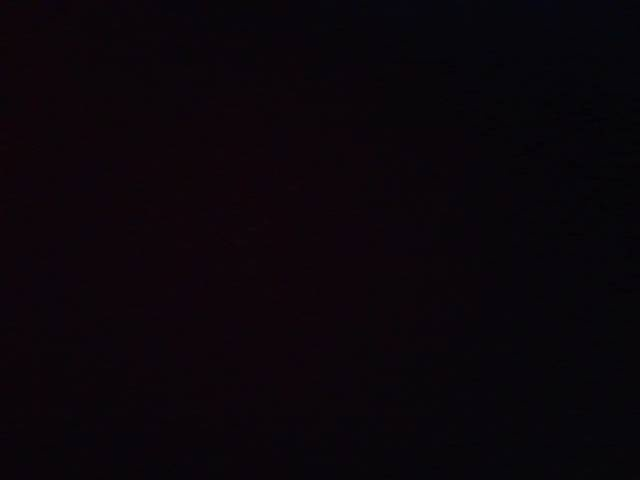

In [11]:
frame = get_webcam_frame()

print("✅ Webcam frame received!")
print("Frame size:", frame.shape)

display(
    Image(
        data=cv2.imencode(".jpg", frame)[1].tobytes()
    )
)

In [12]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 216ms
Prepared 1 package in 31ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



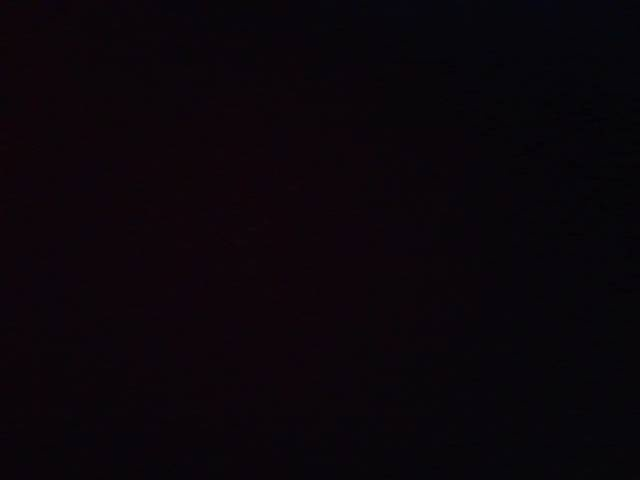

In [13]:
results = model.track(
    frame,
    persist=True,
    tracker="bytetrack.yaml",
    conf=0.10,
    verbose=False
)

annotated = results[0].plot()

display(
    Image(
        data=cv2.imencode(
            ".jpg",
            annotated
        )[1].tobytes()
    )
)

In [2]:
from IPython.display import clear_output

print("Starting webcam tracking...")
print("Stop the cell when you want to finish.")

for i in range(100):

    # Get webcam frame
    frame = get_webcam_frame(quality=0.6)

    # YOLO + ByteTrack
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        conf=0.10,
        verbose=False
    )

    result = results[0]

    # Draw detections
    annotated = result.plot()

    # Count detected classes
    counts = Counter()

    if result.boxes is not None:

        for box in result.boxes:

            class_id = int(box.cls[0])
            class_name = model.names[class_id]

            counts[class_name] += 1

    # Add dashboard
    cv2.rectangle(
        annotated,
        (10, 10),
        (350, 70 + len(counts) * 30),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        annotated,
        "YOLO LIVE",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    y = 70

    for name, count in counts.most_common():

        cv2.putText(
            annotated,
            f"{name}: {count}",
            (20, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )

        y += 25

    # Display frame
    clear_output(wait=True)

    display(
        Image(
            data=cv2.imencode(
                ".jpg",
                annotated
            )[1].tobytes()
        )
    )

Starting webcam tracking...
Stop the cell when you want to finish.


NameError: name 'get_webcam_frame' is not defined

## 6. Inspect individual tracking IDs

If you want to see the ID assigned to every currently tracked object, use this version of the loop.

Example:

`person | ID: 4`

`cell phone | ID: 7`

The ID is intended to remain associated with the same object while the tracker can maintain that identity.


In [ ]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam.")

while True:
    success, frame = cap.read()

    if not success:
        break

    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        conf=0.15,
        verbose=False
    )

    result = results[0]
    annotated = frame.copy()

    if result.boxes is not None:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])

            # Tracking ID may not exist for every detection.
            if box.id is not None:
                track_id = int(box.id[0])
                label = f"{class_name} | ID: {track_id} | {confidence:.2f}"
            else:
                label = f"{class_name} | {confidence:.2f}"

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            cv2.rectangle(
                annotated,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            cv2.putText(
                annotated,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (0, 255, 0),
                2
            )

    cv2.imshow("YOLO Live Tracking - IDs", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


## 7. Important: why a phone may still be missed

A pretrained general-purpose YOLO model does not guarantee that every phone will be detected in every frame.

Phones are small objects, so detection can improve if you:

1. Hold the phone closer to the webcam.
2. Use good lighting.
3. Increase webcam resolution.
4. Lower `conf` from `0.15` to `0.10` for testing.
5. Use a larger YOLO model if your computer can handle it.
6. Train a custom model if phone detection is a core requirement.

For example:

```python
conf=0.10
```

can make the detector more sensitive, but it can also produce more false detections.


## 8. What this version is ready for

Once the live tracking works, the next project layer can add:

- line-crossing IN/OUT counting
- unique object counts
- per-class analytics
- object-entry timestamps
- database storage
- charts
- Streamlit/FastAPI dashboard
- deployment

Recommended production architecture:

**Camera/CCTV → OpenCV/RTSP → YOLO → ByteTrack → Analytics → Database → Web Dashboard**
